<a href="https://colab.research.google.com/github/imaniiz/CariSurg-Healthcare-AI-Training-Program-Week-0-/blob/main/Assignment3_DataVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 - Data Visualization

In [1]:
# Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")

Mounted at /content/drive
Drive mounted successfully!


In [2]:
# Importing emergency triage dataset
FILE_PATH = '/content/drive/MyDrive/Carisurg_Week0/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# Applying all cleaning from Days 1 & 2

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()



Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


# Clinical Question 1: Do patients with higher body temperatures tend to have elevated heart rates?

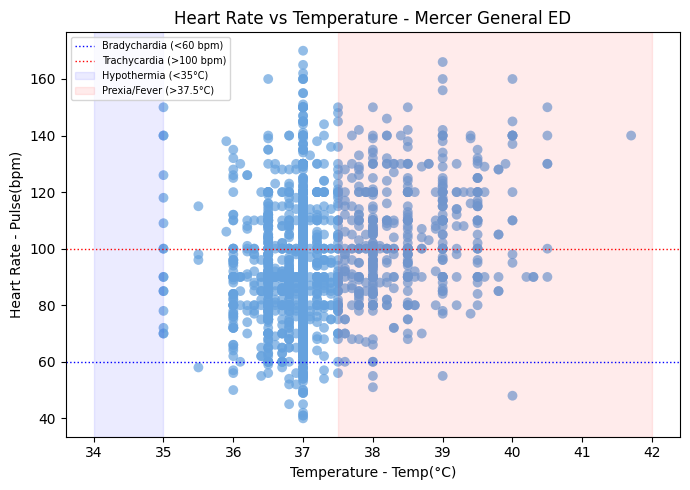

Saved: Pulse_vs_Temp.png


In [49]:
# Scatter Plot showing heart rate vs temperature
fig, ax = plt.subplots(figsize=(7,5))

scatter = ax.scatter(df['Temp'], df['pulse'],
alpha = 0.7, s = 50, color = '#66a2de', edgecolors = 'none')

# Labelling plot axes
ax.set_title('Heart Rate vs Temperature - Mercer General ED')
ax.set_xlabel('Temperature - Temp(°C)')
ax.set_ylabel('Heart Rate - Pulse(bpm)')

# Clinical reference lines
# Adding heart rate regions
ax.axhline(y=60, color='blue', linestyle=':', linewidth=1, label='Bradychardia (<60 bpm)')
ax.axhline(y=100, color='red', linestyle=':', linewidth=1, label='Trachycardia (>100 bpm)')

# Adding temperature regions
ax.axvspan(34, 35, alpha=0.08, color='blue', label='Hypothermia (<35°C)')
ax.axvspan(37.5, 42, alpha=0.08, color='red', label='Prexia/Fever (>37.5°C)')
ax.legend(loc = 'upper left', fontsize=7)

# Saving plot
plt.tight_layout()
plt.savefig('Pulse_vs_Temp.png', dpi = 100, bbox_inches = 'tight')
plt.show()
print("Saved: Pulse_vs_Temp.png")

# Clinical Question 2: How many patients require increased oxygen support compared to those who didn't?

In [34]:
# Number of individual entries under Fio2 column
print("Unique FiO2 values:", df['Fio2'].unique())

Unique FiO2 values: [ 21. 100.  40.  60.  95.  80.  70.]


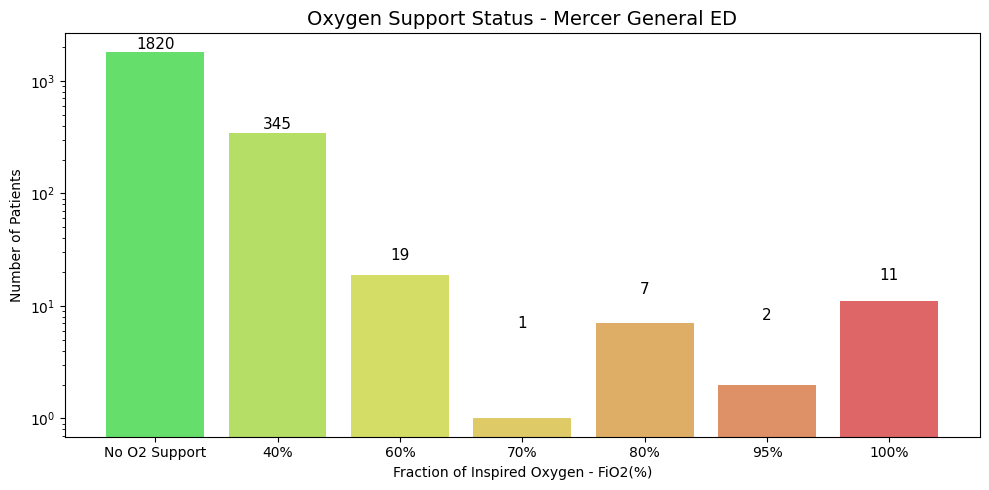

Saved: oxygen_support_status.png


In [50]:
# Bar Plot: Oxygen support status
fig, ax = plt.subplots(figsize=(10,5))

counts = df['Fio2'].value_counts().sort_index()
bars = ax.bar(['No O2 Support', '40%', '60%', '70%', '80%','95%', '100%'],
              counts.values, color = ['#66de6c', '#b4de66', '#d4de66', '#deca66', '#deae66', '#de9066','#de6666' ])

# Adding count labels on top of each bar
for bar, count in zip(bars, counts.values):
  ax.text(bar.get_x()+ bar.get_width()/2, bar.get_height() + 5, str(count),
          ha = 'center', va = 'bottom', fontsize = 11)

# Adding labels
ax.set_title('Oxygen Support Status - Mercer General ED', fontsize=14)
ax.set_xlabel('Fraction of Inspired Oxygen - FiO2(%)')
ax.set_ylabel('Number of Patients')
ax.set_yscale('log')


plt.tight_layout()
plt.savefig('oxygen_support_status.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: oxygen_support_status.png")
